# Задание 5 — Graph Convolutional Network

Граф Amazon Photo: вершина — товар (фототехника), ребро — что товары часто покупают вместе.
Нужно по товару предсказать его категорию (одну из 8).

In [1]:
import copy
import itertools
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.datasets import Amazon
from torch_geometric.nn import GCNConv
from torch_geometric.utils import degree

from sklearn.metrics import classification_report, confusion_matrix

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.figsize": (10, 5), "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.3})

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

/home/dabzelos/Desktop/academic-comeback/ml/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device: cuda


## 1. Датасет — Amazon Photo


In [2]:
dataset = Amazon(root="data/Amazon", name="Photo")
data = dataset[0].to(device)

NUM_CLASSES = dataset.num_classes
CLASS_NAMES = [f"кат. {i}" for i in range(NUM_CLASSES)]

print(f"вершин:    {data.num_nodes}")
print(f"рёбер:     {data.num_edges}")
print(f"признаков: {dataset.num_node_features}")
print(f"классов:   {NUM_CLASSES}")
print(f"неориентированный: {data.is_undirected()},  петли: {data.has_self_loops()}")

вершин:    7650
рёбер:     238162
признаков: 745
классов:   8
неориентированный: True,  петли: False


### Разделяем на выборки

In [3]:
def make_split(y, n_train=20, n_val=30, seed=42):
    y_cpu = y.cpu()
    g = torch.Generator().manual_seed(seed)
    train = torch.zeros(y_cpu.numel(), dtype=torch.bool)
    val   = torch.zeros(y_cpu.numel(), dtype=torch.bool)
    test  = torch.zeros(y_cpu.numel(), dtype=torch.bool)
    for c in y_cpu.unique():
        idx = (y_cpu == c).nonzero(as_tuple=False).view(-1)
        idx = idx[torch.randperm(idx.numel(), generator=g)]
        train[idx[:n_train]] = True
        val[idx[n_train:n_train + n_val]] = True
        test[idx[n_train + n_val:]] = True
    return train, val, test


data.train_mask, data.val_mask, data.test_mask = (m.to(device) for m in make_split(data.y))
print(f"train / val / test: {int(data.train_mask.sum())} / "
      f"{int(data.val_mask.sum())} / {int(data.test_mask.sum())}")

train / val / test: 160 / 240 / 7250


## 2. EDA

In [4]:
labels = data.y.cpu().numpy()
deg = degree(data.edge_index[0], num_nodes=data.num_nodes).cpu().numpy()

edge_homophily = (data.y[data.edge_index[0]] == data.y[data.edge_index[1]]).float().mean().item()
feat_density = (data.x != 0).float().mean().item()

print(f"степень вершины (min/avg/median/max): "
      f"{deg.min():.0f} / {deg.mean():.2f} / {np.median(deg):.0f} / {deg.max():.0f}")
print(f"гомофилия рёбер:        {edge_homophily:.3f}  (доля рёбер внутри одного класса)")
print(f"плотность признаков:    {feat_density:.4f}  "
      f"(~{feat_density*dataset.num_node_features:.0f} ненулевых слов из {dataset.num_node_features})")

степень вершины (min/avg/median/max): 0 / 31.13 / 22 / 1434
гомофилия рёбер:        0.827  (доля рёбер внутри одного класса)
плотность признаков:    0.3474  (~259 ненулевых слов из 745)


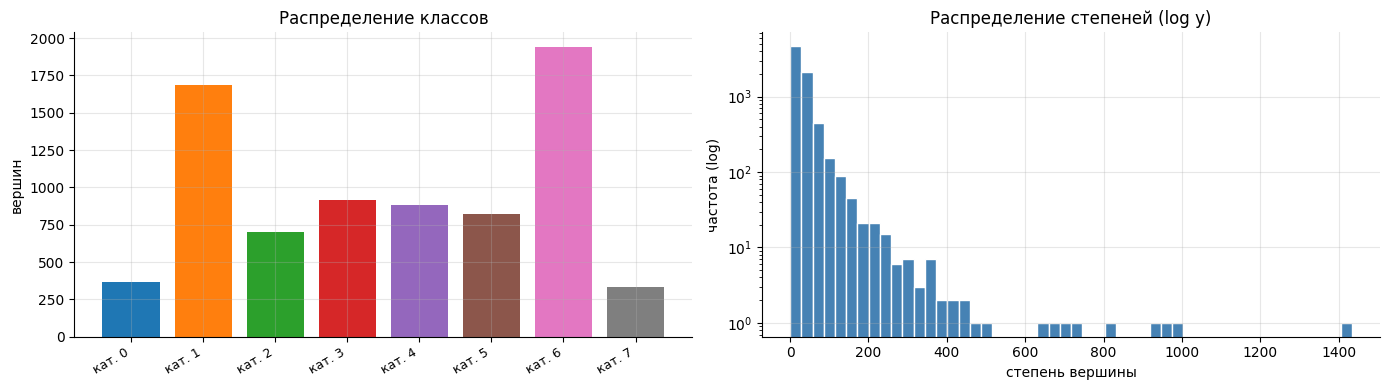

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

counts = np.bincount(labels)
axes[0].bar(range(NUM_CLASSES), counts, color=sns.color_palette("tab10", NUM_CLASSES))
axes[0].set_xticks(range(NUM_CLASSES)); axes[0].set_xticklabels(CLASS_NAMES, rotation=30, ha="right", fontsize=9)
axes[0].set_ylabel("вершин"); axes[0].set_title("Распределение классов")

axes[1].hist(deg, bins=50, color="steelblue", edgecolor="white")
axes[1].set_yscale("log")
axes[1].set_title("Распределение степеней (log y)")
axes[1].set_xlabel("степень вершины"); axes[1].set_ylabel("частота (log)")

plt.tight_layout(); plt.show()

Что видно:
- классы разного размера330 до 1940 вершин
- граф плотный:
- гомофилия ~ 0.83 — больше четырёх из пяти рёбер соединяют товары одной категории

## 3. Модель GCN


In [6]:
class GCN(nn.Module):
    """GCN на готовом слое GCNConv из PyG."""
    def __init__(self, in_ch, hidden_ch, out_ch, num_layers=2, dropout=0.5):
        super().__init__()
        dims = [in_ch] + [hidden_ch] * (num_layers - 1) + [out_ch]
        self.layers = nn.ModuleList(GCNConv(a, b) for a, b in zip(dims, dims[1:]))
        self.dropout = dropout

    def forward(self, x, edge_index):
        *hidden, last = self.layers
        for layer in hidden:
            x = F.relu(layer(x, edge_index))
            x = F.dropout(x, p=self.dropout, training=self.training)
        return last(x, edge_index)

In [7]:
def train_eval(model, logits_fn, data, lr=0.01, epochs=200, weight_decay=5e-4, patience=30):
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    best_val, best_state, best_ep, wait = 0.0, copy.deepcopy(model.state_dict()), 0, 0
    hist = {"loss": [], "val": []}

    for ep in range(epochs):
        model.train(); opt.zero_grad()
        out = logits_fn(model)
        loss = F.cross_entropy(out[data.train_mask], data.y[data.train_mask])
        loss.backward(); opt.step()

        model.eval()
        with torch.no_grad():
            val = logits_fn(model).argmax(1)[data.val_mask].eq(
                  data.y[data.val_mask]).float().mean().item()
        hist["loss"].append(loss.item()); hist["val"].append(val)

        if val > best_val:
            best_val, best_state, best_ep, wait = val, copy.deepcopy(model.state_dict()), ep, 0
        else:
            wait += 1
            if wait >= patience:
                break

    model.load_state_dict(best_state)   # откатываемся к лучшей по val эпохе
    return hist, best_val, best_ep


@torch.no_grad()
def test_accuracy(model, logits_fn, data):
    model.eval()
    pred = logits_fn(model).argmax(1)
    return pred[data.test_mask].eq(data.y[data.test_mask]).float().mean().item()

f_gcn = lambda m: m(data.x, data.edge_index)

IN, OUT = dataset.num_node_features, NUM_CLASSES

## 4. GCN: подбираем гиперпараметры

Пробуем разные lr, размер скрытого слоя и dropout (слоёв берём 2). Для каждого набора смотрим
точность на val и берём лучший. В test пока не заглядываем — он только для финальной проверки.

In [8]:
param_grid = {
    "lr":        [0.005, 0.01, 0.05],
    "hidden_ch": [16, 64, 128],
    "dropout":   [0.5, 0.7],
}
configs = list(itertools.product(*param_grid.values()))
print(f"конфигураций: {len(configs)}")

rows = []
for lr, hidden_ch, dropout in configs:
    torch.manual_seed(0)
    model = GCN(IN, hidden_ch, OUT, num_layers=2, dropout=dropout).to(device)
    _, val, ep = train_eval(model, f_gcn, data, lr=lr, epochs=200)
    rows.append(dict(lr=lr, hidden_ch=hidden_ch, dropout=dropout, val_acc=val, best_epoch=ep))

grid_df = pd.DataFrame(rows).sort_values("val_acc", ascending=False).reset_index(drop=True)
best = grid_df.iloc[0].to_dict()
print(f"\nлучшая конфигурация: lr={best['lr']}, hidden={int(best['hidden_ch'])}, "
      f"dropout={best['dropout']}  ->  val {best['val_acc']:.3f}")
grid_df.head(5)

конфигураций: 18



лучшая конфигурация: lr=0.01, hidden=64, dropout=0.5  ->  val 0.917


,lr,hidden_ch,dropout,val_acc,best_epoch
0,0.010,64,0.5,0.916667,104
1,0.010,64,0.7,0.912500,119
2,0.005,64,0.5,0.908333,91
3,0.005,128,0.7,0.904167,87
4,0.010,128,0.7,0.904167,58


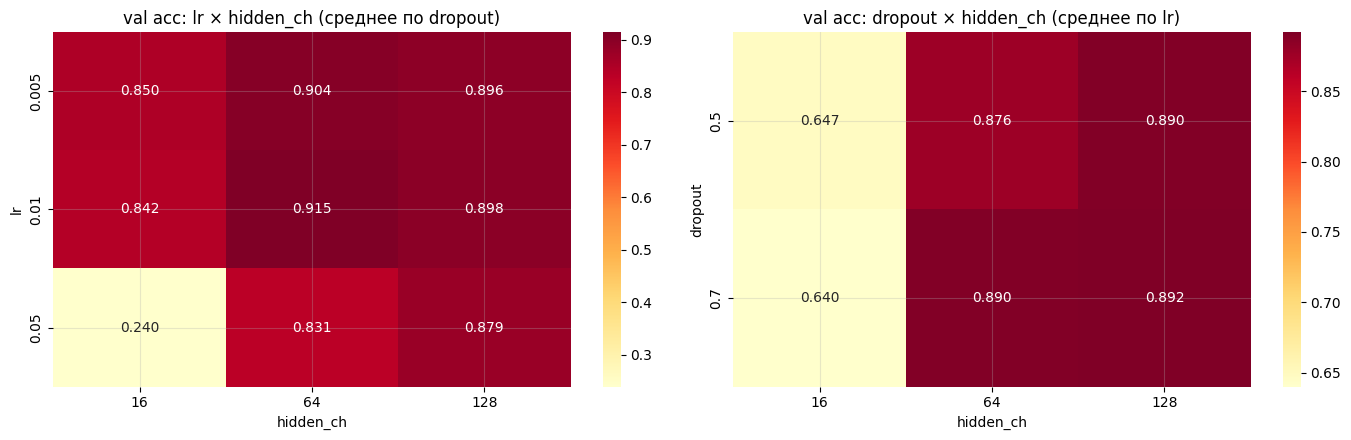

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

p1 = grid_df.groupby(["lr", "hidden_ch"])["val_acc"].mean().unstack()
sns.heatmap(p1, annot=True, fmt=".3f", cmap="YlOrRd", ax=axes[0])
axes[0].set_title("val acc: lr × hidden_ch (среднее по dropout)")

p2 = grid_df.groupby(["dropout", "hidden_ch"])["val_acc"].mean().unstack()
sns.heatmap(p2, annot=True, fmt=".3f", cmap="YlOrRd", ax=axes[1])
axes[1].set_title("val acc: dropout × hidden_ch (среднее по lr)")

plt.tight_layout(); plt.show()

## 5. Результирующая GCN на test

GCN (PyG)  val 0.917 | test 0.917  (лучшая эпоха 104)


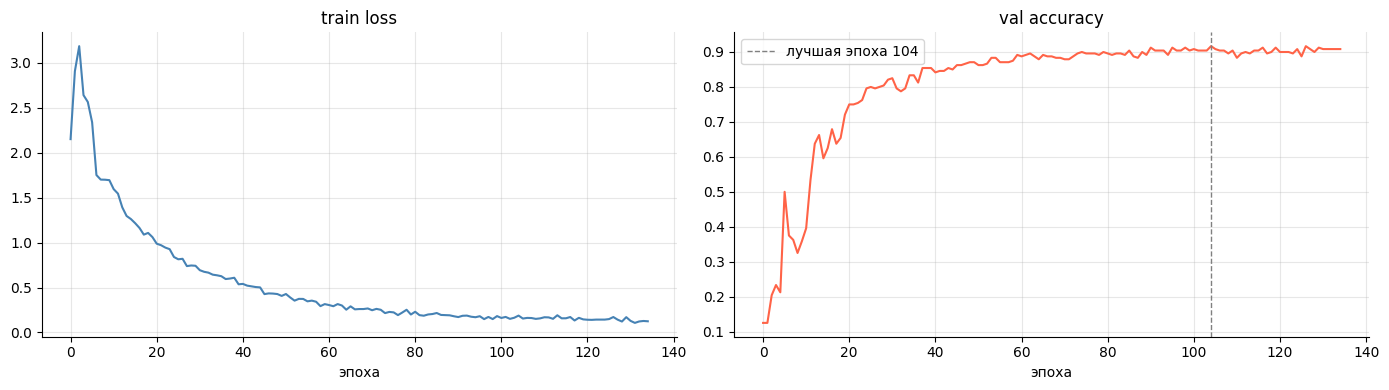

In [10]:
torch.manual_seed(0)
final_gcn = GCN(IN, int(best["hidden_ch"]), OUT, num_layers=2, dropout=best["dropout"]).to(device)
hist_gcn, gcn_val, gcn_ep = train_eval(final_gcn, f_gcn, data, lr=best["lr"], epochs=300)
gcn_test = test_accuracy(final_gcn, f_gcn, data)

print(f"GCN (PyG)  val {gcn_val:.3f} | test {gcn_test:.3f}  (лучшая эпоха {gcn_ep})")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(hist_gcn["loss"], color="steelblue"); axes[0].set_title("train loss"); axes[0].set_xlabel("эпоха")
axes[1].plot(hist_gcn["val"], color="tomato"); axes[1].axvline(gcn_ep, color="gray", ls="--", lw=1, label=f"лучшая эпоха {gcn_ep}")
axes[1].set_title("val accuracy"); axes[1].set_xlabel("эпоха"); axes[1].legend()
plt.tight_layout(); plt.show()

              precision    recall  f1-score   support

      кат. 0      0.843     0.956     0.896       319
      кат. 1      0.966     0.873     0.917      1636
      кат. 2      0.985     0.933     0.958       653
      кат. 3      0.851     0.914     0.882       865
      кат. 4      0.919     0.942     0.931       832
      кат. 5      0.953     0.988     0.970       773
      кат. 6      0.956     0.917     0.936      1891
      кат. 7      0.588     0.822     0.685       281

    accuracy                          0.917      7250
   macro avg      0.883     0.918     0.897      7250
weighted avg      0.924     0.917     0.919      7250



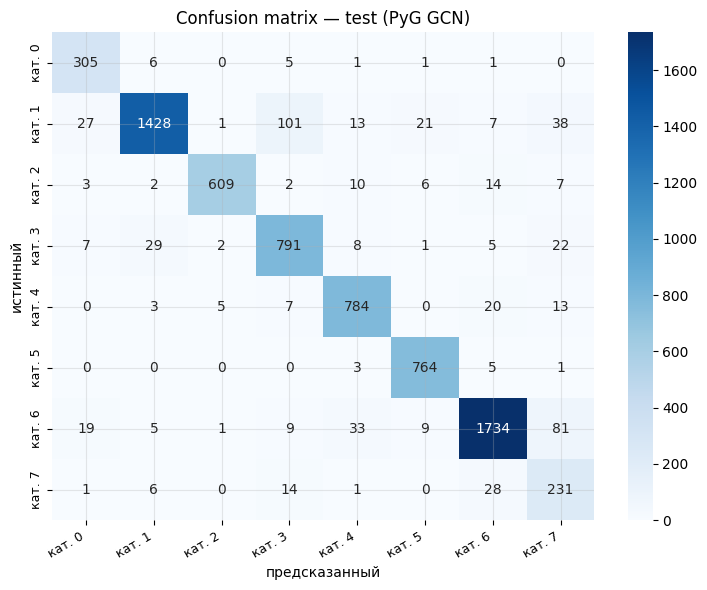

In [11]:
final_gcn.eval()
with torch.no_grad():
    pred = final_gcn(data.x, data.edge_index).argmax(1).cpu().numpy()
mask = data.test_mask.cpu().numpy()
y_true, y_pred = labels[mask], pred[mask]

print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=3))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7.5, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title("Confusion matrix — test (PyG GCN)"); plt.ylabel("истинный"); plt.xlabel("предсказанный")
plt.xticks(rotation=30, ha="right", fontsize=9); plt.yticks(fontsize=9)
plt.tight_layout(); plt.show()

Тут видно что GCN работает хорошо это оусловено гомофилией графа - по соседям можно много понять о самом товаре

## 6. Прогон по нескольким сидам

Train маленький (160 вершин на 8 классов), поэтому результат одного запуска зависит от
случайной инициализации. Обучим GCN 10 раз и посмотрим
среднее и разброс

In [12]:
SEEDS = list(range(10))

def run_seeds(make_model, logits_fn, lr, hidden, dropout, seeds=SEEDS):
    accs = []
    for s in seeds:
        torch.manual_seed(s)
        m = make_model(hidden, dropout).to(device)
        train_eval(m, logits_fn, data, lr=lr, epochs=200)
        accs.append(test_accuracy(m, logits_fn, data))
        del m
        if device.type == "cuda":
            torch.cuda.empty_cache()
    return np.array(accs)

gcn_accs = run_seeds(lambda h, d: GCN(IN, h, OUT, num_layers=2, dropout=d), f_gcn,
                     lr=best["lr"], hidden=int(best["hidden_ch"]), dropout=best["dropout"])

print(f"GCN (PyG)  test acc: {gcn_accs.mean():.3f} ± {gcn_accs.std():.3f}  (10 сидов)")

GCN (PyG)  test acc: 0.904 ± 0.023  (10 сидов)


## 7. Своя реализация

In [ ]:
def normalized_adjacency(edge_index, num_nodes, device):
    A = torch.zeros(num_nodes, num_nodes, device=device)
    A[edge_index[0], edge_index[1]] = 1.0       # связи между вершинами
    A.fill_diagonal_(1.0)                        # каждая вершина соединена сама с собой
    inv_sqrt = A.sum(dim=1).pow(-0.5)            # 1 / sqrt(числа соседей)
    return inv_sqrt[:, None] * A * inv_sqrt[None, :]


class GraphConvLayer(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.lin = nn.Linear(in_ch, out_ch, bias=False)
        self.bias = nn.Parameter(torch.zeros(out_ch))

    def forward(self, x, adj):
        return adj @ self.lin(x) + self.bias     # bias добавляем уже после усреднения


class DenseGCN(nn.Module):
    def __init__(self, in_ch, hidden_ch, out_ch, num_layers=2, dropout=0.5):
        super().__init__()
        dims = [in_ch] + [hidden_ch] * (num_layers - 1) + [out_ch]
        self.layers = nn.ModuleList(GraphConvLayer(a, b) for a, b in zip(dims, dims[1:]))
        self.dropout = dropout

    def forward(self, x, adj):
        *hidden, last = self.layers
        for layer in hidden:
            x = F.relu(layer(x, adj))
            x = F.dropout(x, p=self.dropout, training=self.training)
        return last(x, adj)


adj_norm = normalized_adjacency(data.edge_index, data.num_nodes, device)

### Повторяю обучение
проверяем что 
1. наша матрица соседей совпадает с той, что строит PyG (`gcn_norm`);
2. при одинаковых весах выход нашего слоя совпадает с `GCNConv`.

In [14]:
from torch_geometric.nn.conv.gcn_conv import gcn_norm

# (1) наша матрица соседей совпадает с тем, что строит PyG
ei, ew = gcn_norm(data.edge_index, num_nodes=data.num_nodes, add_self_loops=True)
A_pyg = torch.zeros(data.num_nodes, data.num_nodes, device=device)
A_pyg[ei[0], ei[1]] = ew
assert torch.allclose(adj_norm, A_pyg, atol=1e-6), "матрица соседей не совпадает с gcn_norm!"
print("(1) матрица соседей совпала с тем, что строит PyG   ✓")
del A_pyg
if device.type == "cuda": torch.cuda.empty_cache()

# (2) при одинаковых весах выход нашего слоя совпадает с GCNConv
torch.manual_seed(0)
pyg_layer = GCNConv(IN, 32).to(device)
our_layer = GraphConvLayer(IN, 32).to(device)
with torch.no_grad():
    our_layer.lin.weight.copy_(pyg_layer.lin.weight)   # обе матрицы весов в форме [out, in]
    our_layer.bias.copy_(pyg_layer.bias)
    out_pyg = pyg_layer(data.x, data.edge_index)
    out_our = our_layer(data.x, adj_norm)
max_diff = (out_pyg - out_our).abs().max().item()
assert max_diff < 1e-4, f"выходы расходятся: {max_diff}"
print(f"(2) выход нашего слоя совпал с GCNConv (макс. разница = {max_diff:.1e})  ✓")

(1) матрица соседей совпала с тем, что строит PyG   ✓
(2) выход нашего слоя совпал с GCNConv (макс. разница = 4.8e-06)  ✓


### Обучаем свою GCN и сравниваем

In [ ]:
f_custom = lambda m: m(data.x, adj_norm)

custom_accs = run_seeds(
    lambda h, d: DenseGCN(IN, h, OUT, num_layers=2, dropout=d), f_custom,
    lr=best["lr"], hidden=int(best["hidden_ch"]), dropout=best["dropout"])

torch.manual_seed(0)
custom_gcn = DenseGCN(IN, int(best["hidden_ch"]), OUT, num_layers=2, dropout=best["dropout"]).to(device)
hist_custom, custom_val, custom_ep = train_eval(custom_gcn, f_custom, data, lr=best["lr"], epochs=300)
custom_test = test_accuracy(custom_gcn, f_custom, data)
print(f"Custom GCN  val {custom_val:.3f} | test {custom_test:.3f}")

Custom GCN  val 0.896 | test 0.901


## 8. Сравнение: PyG vs своя реализация

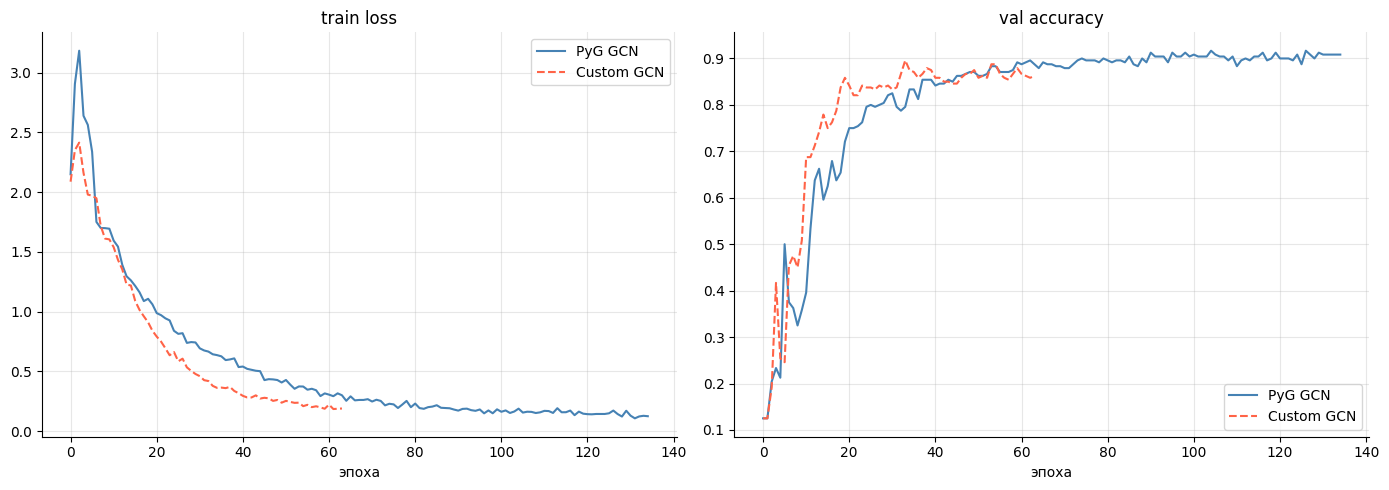

модель           test acc (mean ± std, 10 сидов)
────────────────────────────────────────────────
GCN (PyG)                    0.904 ± 0.023
GCN (своя)                   0.908 ± 0.005


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(hist_gcn["loss"], label="PyG GCN", color="steelblue")
axes[0].plot(hist_custom["loss"], label="Custom GCN", color="tomato", ls="--")
axes[0].set_title("train loss"); axes[0].set_xlabel("эпоха"); axes[0].legend()
axes[1].plot(hist_gcn["val"], label="PyG GCN", color="steelblue")
axes[1].plot(hist_custom["val"], label="Custom GCN", color="tomato", ls="--")
axes[1].set_title("val accuracy"); axes[1].set_xlabel("эпоха"); axes[1].legend()
plt.tight_layout(); plt.show()

print(f"{'модель':<14}{'test acc (mean ± std, 10 сидов)':>34}")
print("─" * 48)
print(f"{'GCN (PyG)':<14}{gcn_accs.mean():>20.3f} ± {gcn_accs.std():.3f}")
print(f"{'GCN (своя)':<14}{custom_accs.mean():>20.3f} ± {custom_accs.std():.3f}")

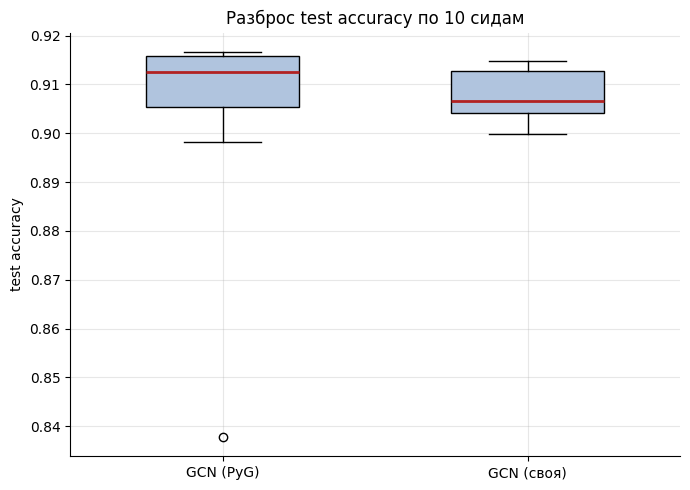

In [17]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.boxplot([gcn_accs, custom_accs], labels=["GCN (PyG)", "GCN (своя)"],
           widths=0.5, patch_artist=True,
           boxprops=dict(facecolor="lightsteelblue"), medianprops=dict(color="firebrick", lw=2))
ax.set_ylabel("test accuracy"); ax.set_title("Разброс test accuracy по 10 сидам")
plt.tight_layout(); plt.show()

## Выводы

GCN хорошо классифицирует товары (~0.90 test-accuracy). Работает это за счёт высокой
гомофилии (0.83) — соседи почти всегда той же категории, и усреднение их признаков
подтягивает вершину к нужному классу.

Своя реализация совпадает с PyG. Проверено численно: и матрица соседей, и выход слоя
совпадают с PyG. Поэтому средние test-accuracy и разброс по сидам у PyG и своей GCN почти
одинаковые — разница только от случайности обучения.
